# Bayesian optimization validation notebook

This notebook validates the BAX Platform starter workflow with reusable Python code from `python/bax_platform`. It uses `temperature` and `pressure` as inputs, maximizes `yield`, and targets `median = 10`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'python').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str((PROJECT_ROOT / 'python').resolve()))
from bax_platform import InputSpec, ObjectiveSpec, make_grid, recommend_next, synthetic_experiment

CSV_PATH = PROJECT_ROOT / 'notebooks' / 'sample_bo_starting_points.csv'
INPUTS = [
    InputSpec('temperature', 200, 300, 10),
    InputSpec('pressure', 20, 60, 4),
]
OBJECTIVES = [
    ObjectiveSpec('yield', 'maximize'),
    ObjectiveSpec('median', 'target', target=10),
]
BETA = 1.2
pd.set_option('display.max_rows', 30)
pd.set_option('display.precision', 3)

In [2]:
def make_starting_csv(path=CSV_PATH):
    starting_points = [
        (200, 20), (200, 40), (200, 60),
        (230, 28), (230, 52),
        (250, 36), (250, 44),
        (270, 28), (270, 52),
        (300, 20), (300, 40), (300, 60),
    ]
    rows = []
    for temperature, pressure in starting_points:
        yld, med = synthetic_experiment(temperature, pressure)
        rows.append({
            'temperature': temperature,
            'pressure': pressure,
            'yield': round(yld, 3),
            'median': round(med, 3),
        })
    sample = pd.DataFrame(rows)
    sample.to_csv(path, index=False)
    return sample

if not CSV_PATH.exists():
    make_starting_csv()

data = pd.read_csv(CSV_PATH)
display(data)

,temperature,pressure,yield,median
0,200,20,0.930,10.426
1,200,40,27.330,7.383
2,200,60,9.730,3.086
3,230,28,64.799,11.309
4,230,52,59.785,6.818
5,250,36,81.179,11.484
6,250,44,78.484,9.968
7,270,28,70.462,13.995
8,270,52,68.724,9.503
9,300,20,16.013,16.547


In [3]:
ranked, measured, measured_front = recommend_next(data, INPUTS, OBJECTIVES, beta=BETA)
print('Recommended next experiment:')
display(ranked.head(1))
print('Top 10 candidates:')
display(ranked.head(10))
print('Measured Pareto front:')
display(measured_front)

Recommended next experiment:


,temperature,pressure,predicted_yield,uncertainty_yield,predicted_median,uncertainty_median,acquisition_score
0,240.0,40.0,77.631,0.573,10.075,0.072,0.989


Top 10 candidates:


,temperature,pressure,predicted_yield,uncertainty_yield,predicted_median,uncertainty_median,acquisition_score
0,240.0,40.0,77.631,0.573,10.075,0.072,0.989
1,260.0,48.0,76.091,0.532,9.773,0.067,0.969
2,250.0,40.0,81.629,0.531,10.764,0.067,0.962
3,260.0,44.0,79.426,0.567,10.618,0.072,0.959
4,230.0,36.0,69.647,0.680,10.118,0.086,0.942
5,240.0,36.0,78.028,0.567,10.807,0.072,0.937
6,270.0,48.0,72.340,0.664,10.363,0.084,0.934
7,240.0,44.0,75.479,0.567,9.268,0.072,0.927
8,250.0,48.0,75.980,0.488,9.120,0.062,0.918
9,260.0,40.0,81.263,0.573,11.422,0.072,0.918


Measured Pareto front:


,temperature,pressure,yield,median
5,250,36,81.179,11.484
6,250,44,78.484,9.968


In [4]:
truth = make_grid(INPUTS)
truth[['yield', 'median']] = truth.apply(
    lambda row: synthetic_experiment(row['temperature'], row['pressure']),
    axis=1,
    result_type='expand',
)
yield_score = (truth['yield'] - truth['yield'].min()) / (truth['yield'].max() - truth['yield'].min())
median_score = 1 - (truth['median'] - 10).abs() / max(truth['median'].std(ddof=1), 1e-9)
truth['combined_true_utility'] = (yield_score + median_score) / 2
print('Best points on the known synthetic surface, for sanity-checking the BO recommendation:')
display(truth.sort_values('combined_true_utility', ascending=False).head(10))

Best points on the known synthetic surface, for sanity-checking the BO recommendation:


,temperature,pressure,yield,median,combined_true_utility
61,250.0,44.0,78.484,9.968,0.978
49,240.0,40.0,77.067,10.068,0.963
73,260.0,48.0,75.505,9.777,0.929
37,230.0,36.0,70.216,10.082,0.918
84,270.0,48.0,73.076,10.395,0.886
72,260.0,44.0,78.881,10.634,0.884
96,280.0,52.0,63.503,10.060,0.880
60,250.0,40.0,80.675,10.764,0.874
48,240.0,36.0,77.600,10.788,0.851
25,220.0,32.0,56.928,10.030,0.844


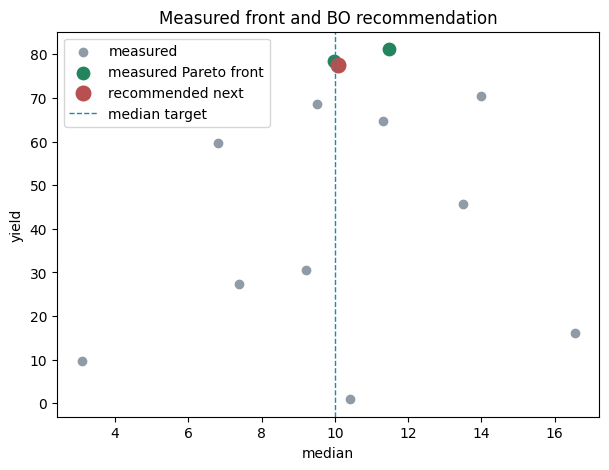

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(measured['median'], measured['yield'], color='#8f9ba7', label='measured')
ax.scatter(measured_front['median'], measured_front['yield'], color='#24845d', s=80, label='measured Pareto front')
next_row = ranked.iloc[0]
ax.scatter(next_row['predicted_median'], next_row['predicted_yield'], color='#b85050', s=110, label='recommended next')
ax.axvline(10, color='#1d8ba8', linestyle='--', linewidth=1, label='median target')
ax.set_xlabel('median')
ax.set_ylabel('yield')
ax.legend()
ax.set_title('Measured front and BO recommendation')
plt.show()